In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Circle

D:\Users\Boris\AppData\Local\Temp\ipykernel_21960\162754836.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
a = 2.5
u = 2.0

x = np.linspace(-10, 10, 500)
y = np.linspace(-10, 10, 500)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

In [3]:
def complex_potential(z, u, a):
    return u * z + u * a ** 2 / z


def stream_function(z, u, a):
    W = complex_potential(z, u, a)
    return np.imag(W)

In [4]:
path_name = r"E:\kurs3\new_ans\results\preM_ball.csv"
# path_name = 'ansys_streamlines.csv'

In [5]:
with open(path_name, 'r') as f:
    lines = f.readlines()

header_line = None
for i, line in enumerate(lines):
    if 'X [' in line and 'Y [' in line and 'Velocity [' in line:
        header_line = i
        break

if header_line is None:
    raise ValueError("file error ANSYS")

ansys_data = pd.read_csv(path_name, skiprows=header_line + 1, header=None)
ansys_data.columns = ['X', 'Y', 'Z', 'Velocity']
ansys_x = ansys_data['X'].values
ansys_y = ansys_data['Y'].values
ansys_z = ansys_x + 1j * ansys_y
ansys_psi = stream_function(ansys_z, u, a)

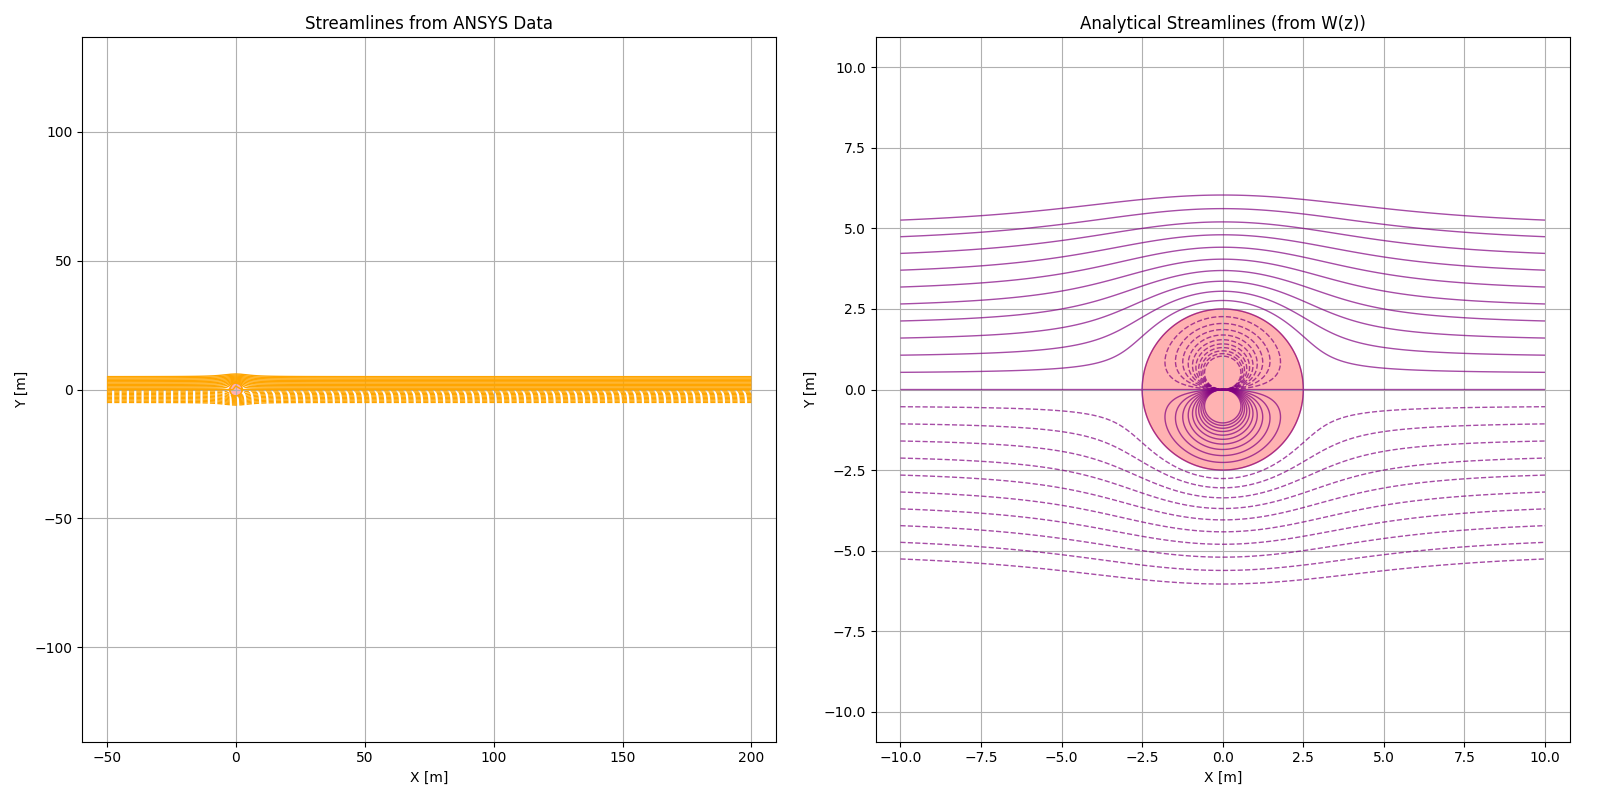

In [6]:
%matplotlib widget
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
from matplotlib.tri import Triangulation

for level in np.linspace(-10, 10, 21):
    plt.tricontour(ansys_data['X'], ansys_data['Y'], ansys_psi, levels=[level], colors='orange', linewidths=1)

plt.gca().add_patch(Circle((0, 0), a, color='red', alpha=0.3))
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Streamlines from ANSYS Data')
plt.grid(True)
plt.axis('equal')

plt.subplot(1, 2, 2)
psi = stream_function(Z, u, a)
for level in np.linspace(-10, 10, 21):
    plt.contour(X, Y, psi, levels=[level], colors='purple', linewidths=1, alpha=0.7)
plt.gca().add_patch(Circle((0, 0), a, color='red', alpha=0.3))
plt.xlabel('X [m]')
plt.ylabel('Y [m]')
plt.title('Analytical Streamlines (from W(z))')
plt.grid(True)
plt.axis('equal')

plt.tight_layout()
plt.show()

In [7]:
def velocity_field(z, u, a):
    return u * (1 - a ** 2 / z ** 2)


def compare_velocities(x_points, y_points, ansys_velocities, u, a):
    results = []
    for x, y, v_ansys in zip(x_points, y_points, ansys_velocities):
        z = x + 1j * y
        if abs(z) < a:
            continue

        W_prime = velocity_field(z, u, a)
        vx = np.real(W_prime)
        vy = -np.imag(W_prime)
        v_analytical = np.sqrt(vx ** 2 + vy ** 2)

        difference = abs(v_analytical - v_ansys)
        relative_diff = difference / v_ansys * 100

        results.append({
            'x': x, 'y': y,
            'ANSYS Velocity': v_ansys,
            'Analytical Velocity': v_analytical,
            'Difference': difference,
            'Relative Difference (%)': relative_diff
        })

    return pd.DataFrame(results)


sample_points = ansys_data.iloc[::20]
comparison = compare_velocities(
    sample_points['X'].values,
    sample_points['Y'].values,
    sample_points['Velocity'].values,
    u, a
)



In [8]:
print("\nVelocity Comparison at Sample Points:")
print(comparison.head(10))

print("\nComparison Statistics:")
print(f"Mean Absolute Difference: {comparison['Difference'].mean():.4f} m/s")
print(f"Max Absolute Difference: {comparison['Difference'].max():.4f} m/s")
print(f"Mean Relative Difference: {comparison['Relative Difference (%)'].mean():.2f}%")
print(f"Max Relative Difference: {comparison['Relative Difference (%)'].max():.2f}%")



Velocity Comparison at Sample Points:
            x          y  ANSYS Velocity  Analytical Velocity  Difference  \
0   42.124668 -12.763179        2.021186             1.994636    0.026549   
1  169.446426  97.081268        1.975303             1.999834    0.024531   
2   61.559410  58.565533        2.004549             1.999914    0.004634   
3  -24.908798 -36.779453        2.003647             2.002360    0.001287   
4  -38.047424  78.336281        2.000193             2.001019    0.000826   
5   50.478989  62.742710        2.004293             2.000414    0.003880   
6  181.162079  43.610195        2.006877             1.999679    0.007198   
7   53.089401  85.326660        2.001284             2.000547    0.000737   
8   88.909935 -23.407944        2.018273             1.998713    0.019560   
9  141.723999   3.614037        1.899176             1.999379    0.100203   

   Relative Difference (%)  
0                 1.313557  
1                 1.241896  
2                 0.231189

In [9]:
first_x = sample_points['X'].values[0]
first_y = sample_points['Y'].values[0]
first_v_ansys = sample_points['Velocity'].values[0]

first_z = first_x + 1j * first_y
W_prime = velocity_field(first_z, u, a)
vx_first = np.real(W_prime)
vy_first = -np.imag(W_prime)
first_v_analytical = np.sqrt(vx_first ** 2 + vy_first ** 2)

print(f"ANSYS Velocity: {first_v_ansys:.4f} m/s")
print(f"Analytical Velocity: {first_v_analytical:.4f} m/s")

ANSYS Velocity: 2.0212 m/s
Analytical Velocity: 1.9946 m/s
